# Предсказание покупательской активности

Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. Сделать это можно с помощью персонализированных предложений.

«В один клик» — современная компания, поэтому её руководство не хочет принимать решения просто так — только на основе анализа данных и бизнес-моделирования.

Отделу поручили разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

Нужно построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца.

**Описание данных**
`market_main`
Таблица, которая содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.


- `id` — номер покупателя в корпоративной базе данных.
- `Покупательская активность` — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».
- `Тип сервиса` — уровень сервиса, например «премиум» и «стандарт». Зависит от наличия определенной подписки у пользователя.
- `Разрешить сообщать` — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.
- `Маркет_актив_6_мес` — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.
- `Маркет_актив_тек_мес` — количество маркетинговых коммуникаций в текущем месяце.
- `Длительность` — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.
- `Акционные_покупки` — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.
- `Популярная_категория` — самая популярная категория товаров у покупателя за последние 6 месяцев.
- `Средний_просмотр_категорий_за_визит` — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.
- `Неоплаченные_продукты_штук_квартал` — общее число неоплаченных товаров в корзине за последние 3 месяца.
- `Ошибка_сервиса` — число сбоев, которые коснулись покупателя во время посещения сайта за последние 3 месяца.
- `Страниц_за_визит` — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.

`market_money`

Таблица с данными о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.

- `id` — номер покупателя в корпоративной базе данных.
- `Период` — название периода, во время которого зафиксирована выручка. Например, `'текущий_месяц'` или `'предыдущий_месяц'`.
- `Выручка` — сумма выручки за период в условных единицах.

`market_time`

Таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода.

- `id` — номер покупателя в корпоративной базе данных.
- `Период` — название периода, во время которого зафиксировано общее время.
- `минут` — значение времени, проведённого на сайте, в минутах.

`money_df`

Таблица с данными о среднемесячной прибыли продавца за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.

- `id` — номер покупателя в корпоративной базе данных.
- `Прибыль` — значение прибыли в условных единицах.

Импортирование библиотек

In [54]:
!pip install matplotlib==3.5.0 -q
!pip install shap==0.40.0 -q
!pip install phik==0.11.1 -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

import phik
    

import shap


warnings.filterwarnings('ignore')

## Загрузка данных

In [14]:
market_main = pd.read_csv('/datasets/market_file.csv')
market_money = pd.read_csv('/datasets/market_money.csv')
market_time = pd.read_csv('/datasets/market_time.csv')
money_df = pd.read_csv('/datasets/money.csv', sep=';', decimal=',')

In [15]:
for df in [market_main, market_money, market_time, money_df]:
    display(df.head())

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


Выведем общую информацию о всех таблицах

In [16]:
for df in [market_main, market_money, market_time, money_df]:
    df.info()
    print('\n/---------------/\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

Предварительно проблем в данных не видно

## Предобработка данных

### Переименование столбцов

В таблице `market_main` заменим все пробелы на `_` и приведём все столбы во всех таблицах к нижнему регистру

In [17]:
for df in [market_main, market_money, market_time, money_df]:
    df.columns = df.columns.str.lower()
    df.columns = df.columns.str.replace(' ', '_')

### Неявные дубликаты

Выведем уникальные значения категориальных переменных всех таблиц

In [18]:
for df in [market_main, market_money, market_time, money_df]:
    for col in df.select_dtypes(exclude='number').columns:
        print(col)
        print(df[col].unique())
        print()

покупательская_активность
['Снизилась' 'Прежний уровень']

тип_сервиса
['премиум' 'стандартт' 'стандарт']

разрешить_сообщать
['да' 'нет']

популярная_категория
['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']

период
['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']

период
['текущий_месяц' 'предыдцщий_месяц']



В значениях есть опечатки, преобразуем их:
- в `тип_сервиса` (market_main) `стандартт` $\to$ `стандарт`
- в `период` (market_money) `препредыдущий_месяц` $\to$ `предпредыдущий_месяц`
- в `период` (market_time) `предыдцщий_месяц` $\to$ `предыдущий_месяц`

In [19]:
market_main.loc[market_main['тип_сервиса'] == 'стандартт', 'тип_сервиса'] = 'стандарт'
market_money.loc[market_money['период'] == 'препредыдущий_месяц', 'период'] = 'предпредыдущий_месяц'
market_time.loc[market_time['период'] == 'предыдцщий_месяц', 'период'] = 'предыдущий_месяц'

Проверим

In [20]:
for df in [market_main, market_money, market_time, money_df]:
    for col in df.select_dtypes(exclude='number').columns:
        print(col)
        print(df[col].unique())
        print()

покупательская_активность
['Снизилась' 'Прежний уровень']

тип_сервиса
['премиум' 'стандарт']

разрешить_сообщать
['да' 'нет']

популярная_категория
['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']

период
['предпредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']

период
['текущий_месяц' 'предыдущий_месяц']



### Обработка явных дубликатов

In [21]:
for df in [market_main, market_money, market_time, money_df]:
    print(df.duplicated().sum())

0
0
0
0


Явных дубликатов нет

### Обработка дубликатов `id`

Выведем кол-во дубликатов в поле `id` во всех таблицах

In [22]:
for df in [market_main, market_money, market_time, money_df]:
    print(df['id'].duplicated().sum())

0
2600
1300
0


В таблицах `market_money` и `market_time` есть повторяющиеся записи о пользователях, возможно это одни и те же пользователи, но за разный период

Выведем кол-во дубликатов в поле `id` в таблицах `market_money` и `market_time` по периодам

In [23]:
for val in market_money['период'].unique():
    print(market_money[market_money['период'] == val]['id'].duplicated().sum(), 
          market_money[market_money['период'] == val]['id'].count())

0 1300
0 1300
0 1300


In [24]:
for val in market_time['период'].unique():
    print(market_time[market_time['период'] == val]['id'].duplicated().sum(), 
          market_time[market_time['период'] == val]['id'].count())

0 1300
0 1300


Дубликатов нет, предположение подтвердилось

### Вывод

Из проблем в данных были замечены опечатки в значениях некоторых столбцов, заказчику рекомендуется ответственней подходить к заполнению данных таблиц

## Исследовательский анализ данных

### Исследование отдельных признаков

In [25]:
# функция вывода характеристик количественного признака
def feature_stat_quant(feature, title, ylabel, bins_count=50):
    fig, axes = plt.subplots(ncols=1, nrows=2, gridspec_kw={'height_ratios' : [15, 85]}, figsize=(8, 5), sharex=True)
    axes[0].boxplot(feature, vert=False)
    axes[0].set_title(title)
    
    axes[1].hist(feature, bins=bins_count)
    axes[1].set_ylabel(ylabel)
    axes[1].axvline(feature.mean(), color='red', linestyle='-', linewidth=2, label=f'Среднее: {feature.mean():.2f}')
    axes[1].axvline(feature.median(), color='red', linestyle='--', linewidth=2, label=f'Медиана: {feature.median():.2f}')
    
    plt.tight_layout()
    plt.legend()
    plt.grid()
    plt.show()
    print(feature.describe().T)
    
# функция для построения графика категориальных переменных
def feature_stat_categ(feature, title_name, ylim=100):
    plt.figure(figsize=(10,6)) 
    
    percent_list = []
    for j in range(len(sorted(feature.unique()))):
        percent_list.append(((feature == sorted(feature.unique())[j]).sum() / feature.size)*100)
        
    bars = plt.bar(sorted(feature.unique()), percent_list,
              color=['blue','skyblue', 'red', 'lightcoral', 'green', 'lightgreen'], alpha=0.8, width=0.6)
    for i, v in enumerate(percent_list):
        plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom')
    plt.xticks(rotation=45)
    plt.title(title_name)
    plt.ylabel('%')
    plt.ylim(0, ylim)
    plt.show()

#### `market_main`

##### `покупательская_активность`

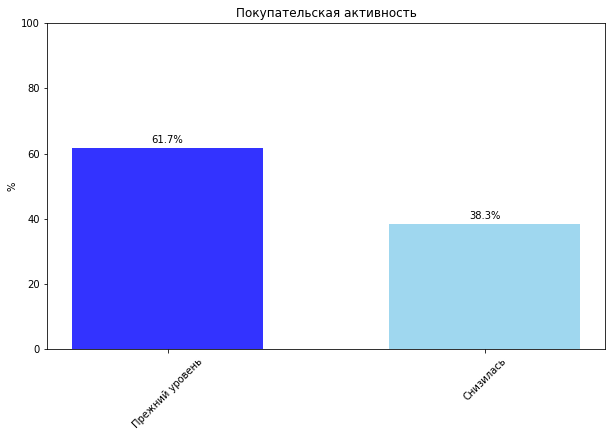

In [26]:
feature_stat_categ(market_main['покупательская_активность'], 'Покупательская активность')

Объектов со значением `Прежний уровень` на 20% больше, чем `Снизилась`

##### `тип_сервиса`

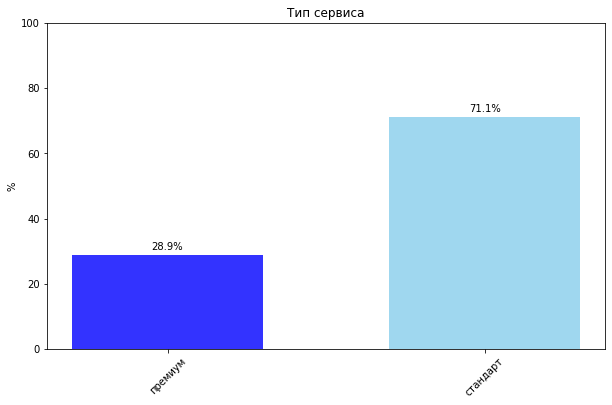

In [27]:
feature_stat_categ(market_main['тип_сервиса'], 'Тип сервиса')

Большая часть покупателей пользуется уровнем сервиса `стандарт`

##### `разрешить_сообщать`

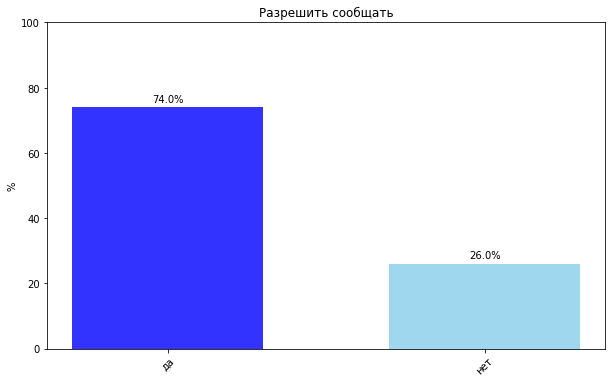

In [28]:
feature_stat_categ(market_main['разрешить_сообщать'], 'Разрешить сообщать')

Большая часть покупателей согласиласб получать дополнительные предложения о товарах

##### `маркет_актив_6_мес`

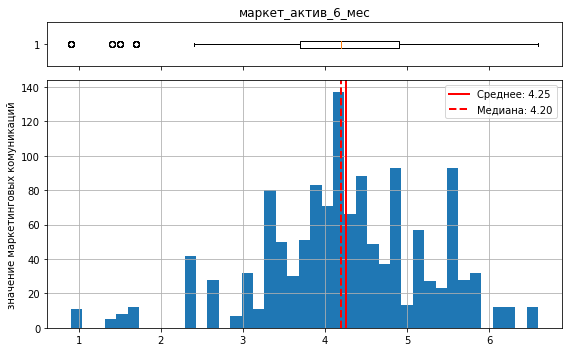

count    1300.000000
mean        4.253769
std         1.014814
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: маркет_актив_6_мес, dtype: float64


In [29]:
feature_stat_quant(market_main['маркет_актив_6_мес'], 'маркет_актив_6_мес', 'значение маркетинговых комуникаций',
                   len(market_main['маркет_актив_6_мес'].unique()))

Значения маркетинговой активности за последние 6 месяцев распределены более-менее нормально, с небольшим количеством выбросов в меньшую сторону

##### `маркет_актив_тек_мес`

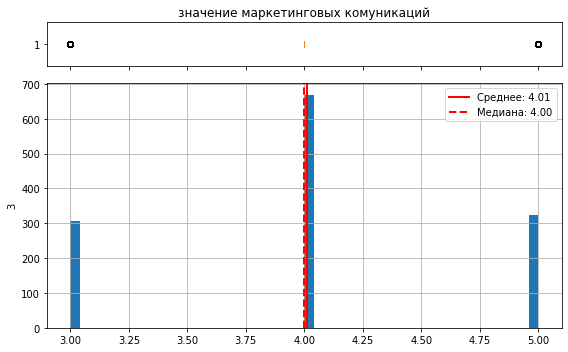

count    1300.000000
mean        4.011538
std         0.696868
min         3.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: маркет_актив_тек_мес, dtype: float64


In [30]:
feature_stat_quant(market_main['маркет_актив_тек_мес'], 'значение маркетинговых комуникаций',
                   len(market_main['маркет_актив_тек_мес'].unique()))

Значения маркетиноговой активности в текущем месяце приинимают всего три значения: 3, 4, 5. Значения распределены нормально

##### `длительность`

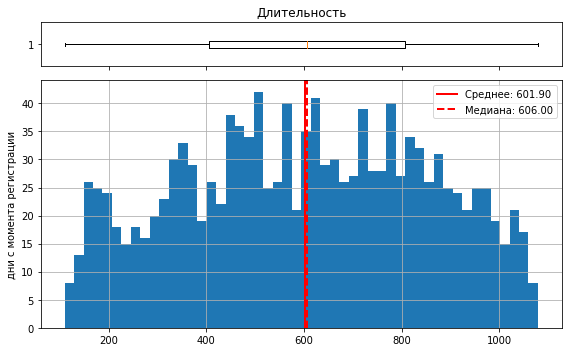

count    1300.000000
mean      601.898462
std       249.856289
min       110.000000
25%       405.500000
50%       606.000000
75%       806.000000
max      1079.000000
Name: длительность, dtype: float64


In [31]:
feature_stat_quant(market_main['длительность'], 'Длительность', 'дни с момента регистрации', 50)

Кол-во дней с момента регистрации на сайте распределено нормально

##### `акционные_покупки`

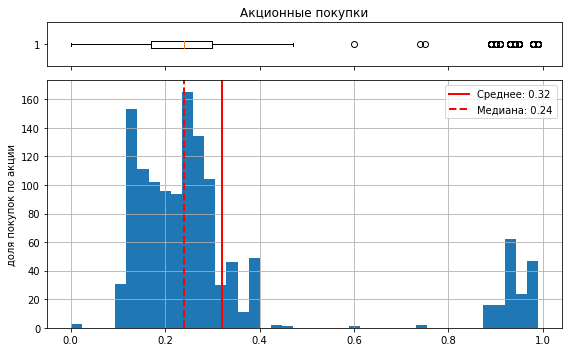

count    1300.000000
mean        0.319808
std         0.249843
min         0.000000
25%         0.170000
50%         0.240000
75%         0.300000
max         0.990000
Name: акционные_покупки, dtype: float64


In [32]:
feature_stat_quant(market_main['акционные_покупки'], 'Акционные покупки', 'доля покупок по акции',
                  len(market_main['акционные_покупки'].unique()))

По доле покупок по акции покупатели разделяются на две группы, те, кто совершает от 10% до 40% покупок по акции (большая часть) и те, кто покупает почти всегда по акции

##### `популярная_категория`

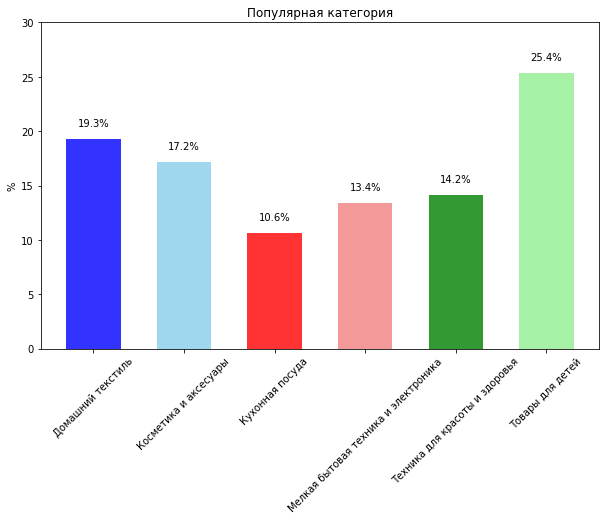

In [33]:
feature_stat_categ(market_main['популярная_категория'], 'Популярная категория', ylim=30)

Самая популярная категория - `Товары для детей`, самая не популярная - `кухонная посуда`. В целом категории распределены более-менее равномерно

##### `средний_просмотр_категорий_за_визит`

In [34]:
market_main['средний_просмотр_категорий_за_визит'].unique()

array([6, 4, 5, 3, 2, 1])

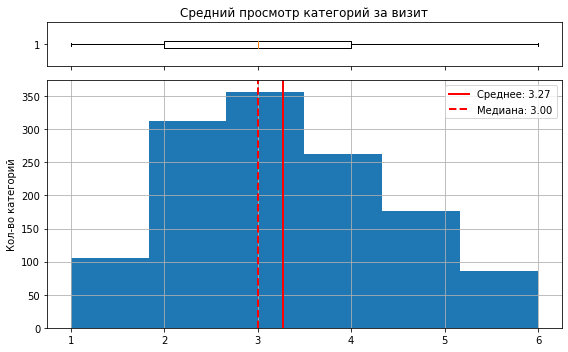

count    1300.00000
mean        3.27000
std         1.35535
min         1.00000
25%         2.00000
50%         3.00000
75%         4.00000
max         6.00000
Name: средний_просмотр_категорий_за_визит, dtype: float64


In [35]:
feature_stat_quant(market_main['средний_просмотр_категорий_за_визит'], 'Средний просмотр категорий за визит',
                   'Кол-во категорий', len(market_main['средний_просмотр_категорий_за_визит'].unique()))

Значения распределены нормально со смещением влево, в среднем покупатель просматривает 3 категории за визит

##### `неоплаченные_продукты_штук_квартал`

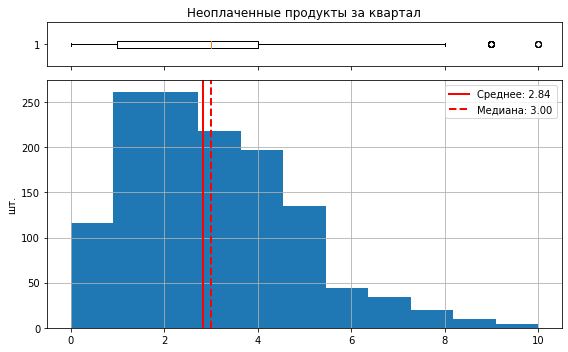

count    1300.000000
mean        2.840000
std         1.971451
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: неоплаченные_продукты_штук_квартал, dtype: float64


In [36]:
feature_stat_quant(market_main['неоплаченные_продукты_штук_квартал'], 'Неоплаченные продукты за квартал',
                   'шт.', len(market_main['неоплаченные_продукты_штук_квартал'].unique()))

Распределение значений сильно смещено влево, в среднем за последние 3 месяца у покупателей 3 неоплаченых товара в корзине

##### `ошибка_сервиса`

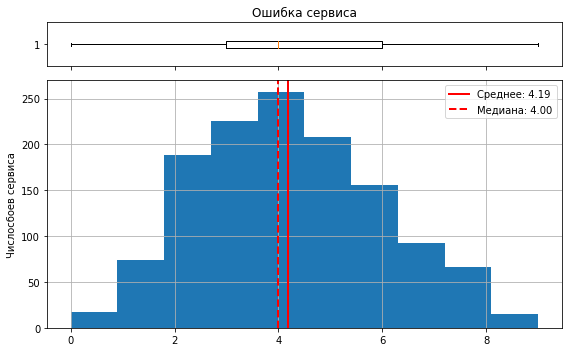

count    1300.000000
mean        4.185385
std         1.955298
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: ошибка_сервиса, dtype: float64


In [37]:
feature_stat_quant(market_main['ошибка_сервиса'], 'Ошибка сервиса', 'Числосбоев сервиса',
                  len(market_main['ошибка_сервиса'].unique()))

Значения распределены нормально, в среднем за последние 3 месяца во время посещения сайта покупатели сталкивались со сбоями 4 раза

##### `страниц_за_визит`

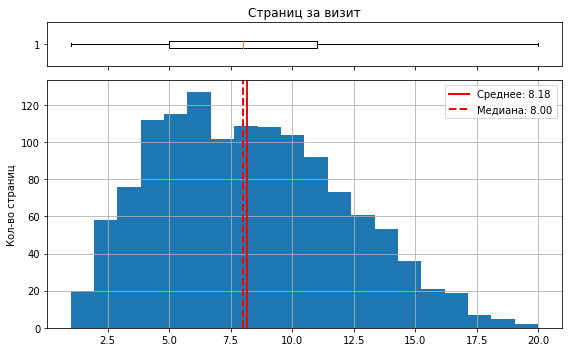

count    1300.000000
mean        8.176923
std         3.978126
min         1.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        20.000000
Name: страниц_за_визит, dtype: float64


In [38]:
feature_stat_quant(market_main['страниц_за_визит'], 'Страниц за визит', 'Кол-во страниц',
                  len(market_main['страниц_за_визит'].unique()))

Значения распределены нормально, в среднем за последние 3 месяца покупатели посещали 8 страниц сайта за визит

#### `market_money`

##### `период`

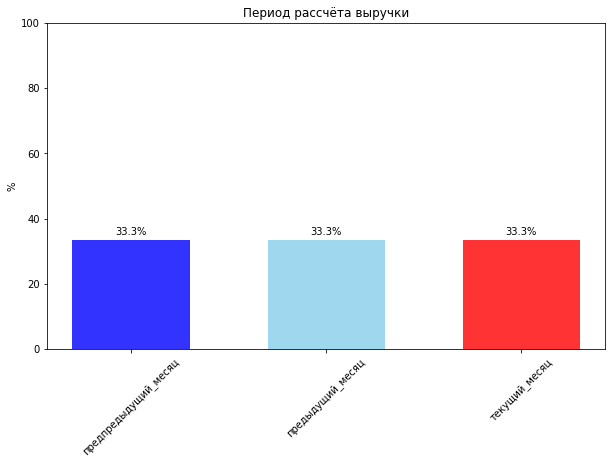

In [39]:
feature_stat_categ(market_money['период'], 'Период рассчёта выручки')

Значения распределены поравну

##### `выручка`

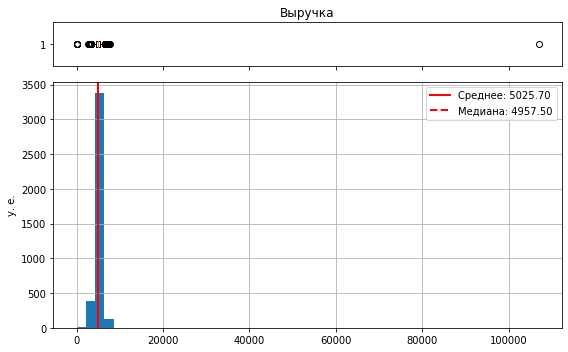

count      3900.000000
mean       5025.696051
std        1777.704104
min           0.000000
25%        4590.150000
50%        4957.500000
75%        5363.000000
max      106862.200000
Name: выручка, dtype: float64


In [40]:
feature_stat_quant(market_money['выручка'], 'Выручка', 'у. е.')

В данных видны большие выбросы, выведем 5 строк с самыми большими значениями выручки

In [41]:
market_money.sort_values(by='выручка', ascending=False).head(5)

,id,период,выручка
98,215380,текущий_месяц,106862.2
435,215493,текущий_месяц,7799.4
262,215435,текущий_месяц,7605.3
1481,215841,текущий_месяц,7557.0
2388,216144,текущий_месяц,7547.8


Выброс только один, такое значение в теории может быть, но оно сильно искажает данные, поэтому удалим его

In [42]:
market_money = market_money.drop(market_money[market_money['выручка'] > 8000].index)

Построим графики без выброса

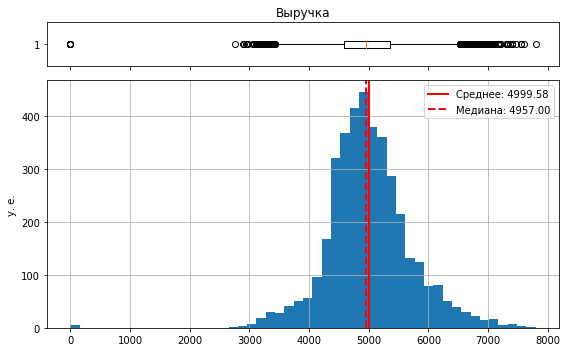

count    3899.00000
mean     4999.57743
std       706.99988
min         0.00000
25%      4590.10000
50%      4957.00000
75%      5363.00000
max      7799.40000
Name: выручка, dtype: float64


In [43]:
feature_stat_quant(market_money['выручка'], 'Выручка', 'у. е.')

Значения распределены нормально, видны выбросы слева

#### `market_time`

##### `период`

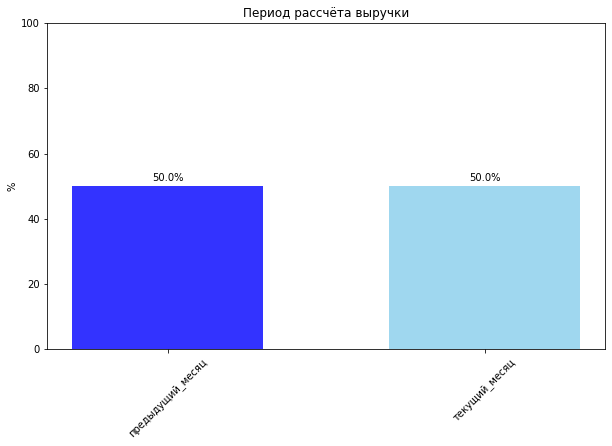

In [44]:
feature_stat_categ(market_time['период'], 'Период рассчёта выручки')

Периоды рассчёта времени посещения сайта распределены поравну

##### `минут`

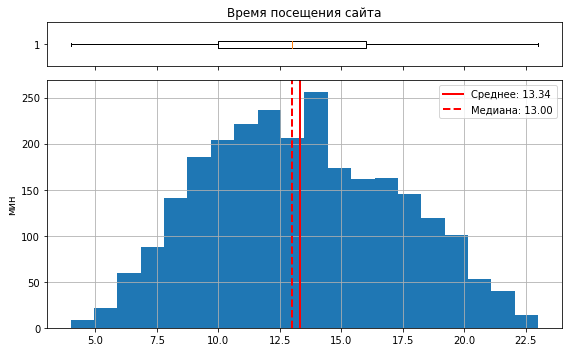

count    2600.000000
mean       13.336154
std         4.080198
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: минут, dtype: float64


In [45]:
feature_stat_quant(market_time['минут'], 'Время посещения сайта', 'мин', len(market_time['минут'].unique()))

Значения распределены нормально, в среднем покупатель проводит на сайте 13 минут

#### `money_df`

##### `прибыль`

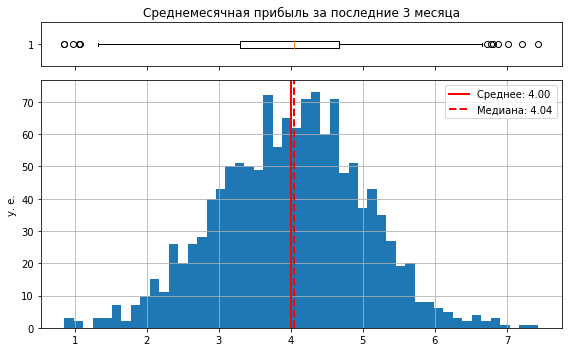

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: прибыль, dtype: float64


In [46]:
feature_stat_quant(money_df['прибыль'], 'Среднемесячная прибыль за последние 3 месяца', 'у. е.')

Значения распределены нормально

### Определение актуальных покупателей

Отберём покупателей, покупавших что-то за последние 3 месяца. 

id всех таких покупателей находятся в таблице `money_df`, т. к. она содержит среднемесячную прибыль с каждого покупателя за последние 3 месяца и в этой таблице нет нулевых значений.

In [47]:
market_money_drop0 = market_money.drop(market_money[market_money['выручка'] == 0].index)
active_customers = market_main.loc[
    (market_main['id'].isin(market_money_drop0[market_money_drop0['период']=='предпредыдущий_месяц']['id'])) & 
    (market_main['id'].isin(market_money_drop0[market_money_drop0['период']=='предыдущий_месяц']['id'])) &
    (market_main['id'].isin(market_money_drop0[market_money_drop0['период']=='текущий_месяц']['id']))
]

### Вывод

Количественные переменные практически все распределены нормально. Проблемными являются только два признака:
- `маркет_актив_тек_мес` принимает всего три значения
- в `акционные_покупки` значения чётко делятся на две группы

Среди категориальных признаков практически все распределены равномерно, кроме:
- `тип_сервиса`
- `разрешить_сообщать`

Была создана таблица с покупателями, совершавшими покупки все три последних месяца

## Объединение таблиц

Объединим таблицы `market_main`, `market_money`, `market_time`. В таблицах `market_money` и `market_time` указаны данные за разные периоды, учтём это.

In [48]:
market_full = active_customers
for time in market_money['период'].unique():
    market_full = market_full.merge(market_money[market_money['период'] == time],
                                   on='id').drop('период', axis=1).rename(columns={'выручка' : 'выручка_'+time})
for time in market_time['период'].unique():
    market_full = market_full.merge(market_time[market_time['период'] == time],
                                   on='id').drop('период', axis=1).rename(columns={'минут' : 'минут_'+time})

In [49]:
market_full.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предпредыдущий_месяц,выручка_текущий_месяц,выручка_предыдущий_месяц,минут_текущий_месяц,минут_предыдущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,4971.6,5216.0,10,12
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5058.4,5457.5,13,8
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6610.4,6158.0,13,11
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5872.5,5807.5,11,8
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,5388.5,4738.5,10,10


## Корреляционный анализ

### Рассчёт коэффициентов корреляции

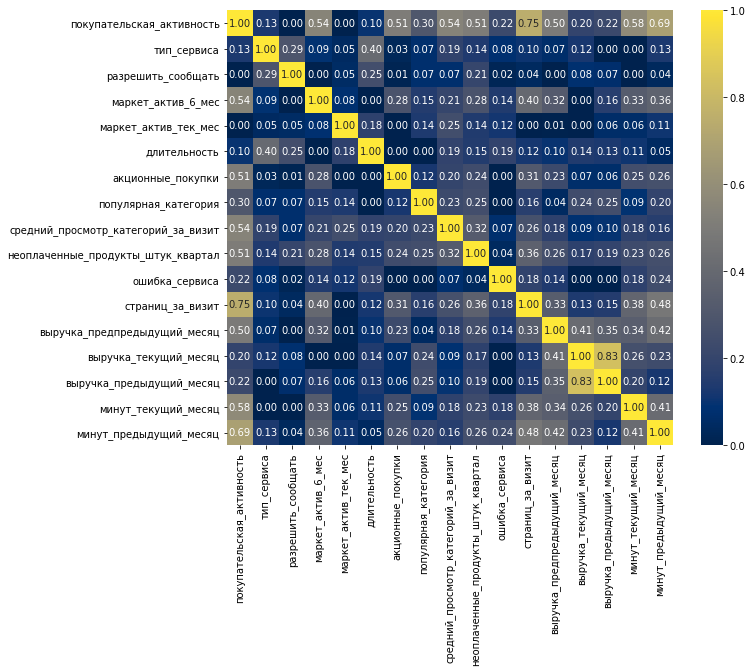

In [50]:
plt.figure(figsize=(10, 8))
sns.heatmap(market_full.drop('id', axis=1).phik_matrix(interval_cols=
                                             market_full.drop('id', axis=1).select_dtypes(include='number').columns
                                            ), annot=True, fmt='.2f', cmap='cividis')
plt.show()

Самая высокая корреляция у целевого признака `покупательская_активность` c признаком `страниц_за_визит`.

Мультиколлинеарности не наблюдается

## Использование пайплайнов

Поделим датасет на тренировочную и тестовую выборки

In [51]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

X_train, X_test, y_train, y_test = train_test_split(
    market_full.drop(['id', 'покупательская_активность'], axis=1),
    market_full['покупательская_активность'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = market_full['покупательская_активность'])

Разделим признаки на типы

In [58]:
# только OHE
ohe_only_columns = ['популярная_категория']

# OHE и OE
cat_columns = market_full.drop(['id', 'покупательская_активность', 'популярная_категория'],
                                   axis=1).select_dtypes(exclude='number').columns.tolist()

# StandardScaler и MinMaxScaler
num_columns = market_full.drop('id', axis=1).select_dtypes(include='number').columns.tolist()

Создадим пайплайны

In [60]:
ohe_only_pipe = Pipeline([
    ('ohe_only', OneHotEncoder(drop='first', sparse=False))
])
cat_pipe = Pipeline([
    ('cat', OneHotEncoder(drop='first', sparse=False))
])

data_preprocessor = ColumnTransformer([
    ('ohe_only', ohe_only_pipe, ohe_only_columns),
    ('cat', cat_pipe, cat_columns),
    ('num', StandardScaler(), num_columns)
])

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

Создадим список гиперпараметров пайплайна

In [85]:
param_grid = [
    # словарь модели kNN
    {
        'models' : [KNeighborsClassifier()],
        'models__n_neighbors' : range(1, 20),
        'preprocessor__ohe_only' : [OneHotEncoder(drop='first', sparse=False)],
        'preprocessor__cat' : [
            OneHotEncoder(drop='first', sparse=False),
            OrdinalEncoder(categories = [['нет', 'да'], ['стандарт', 'премиум']])
        ],
        'preprocessor__num' : [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    
    # словарь модели DecisionTreeClassifier
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 5),
        'models__max_features': range(2, 5),
        'preprocessor__ohe_only' : [OneHotEncoder(drop='first', sparse=False)],
        'preprocessor__cat' : [
            OneHotEncoder(drop='first', sparse=False),
            OrdinalEncoder(categories = [['нет', 'да'], ['стандарт', 'премиум']])
        ],
        'preprocessor__num' : [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    
    # словарь модели LogisticRegression
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 5),
        'preprocessor__ohe_only' : [OneHotEncoder(drop='first', sparse=False)],
        'preprocessor__cat' : [
            OneHotEncoder(drop='first', sparse=False),
            OrdinalEncoder(categories = [['нет', 'да'], ['стандарт', 'премиум']])
        ],
        'preprocessor__num' : [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    
    # словарь модели SVC
    {
        'models' : [SVC(random_state=RANDOM_STATE, probability=True)],
        'models__kernel' : ['rbf', 'sigmoid', 'poly'],
        'preprocessor__ohe_only' : [OneHotEncoder(drop='first', sparse=False)],
        'preprocessor__cat' : [
            OneHotEncoder(drop='first', sparse=False),
            OrdinalEncoder(categories = [['нет', 'да'], ['стандарт', 'премиум']])
        ],
        'preprocessor__num' : [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
]

Создадим объект кросс-валидационного поиска, обучим его, выведем лучшую модель и лучшую метрику.

Будем использовать метрику `ROC-AUC` так как она не зависит от порога классификации 

In [86]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', randomized_search.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe_only',
                                                  OneHotEncoder(drop='first',
                                                                sparse=False),
                                                  ['популярная_категория']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse=False),
                                                  ['тип_сервиса',
                                                   'разрешить_сообщать']),
                                                 ('num', StandardScaler(),
                                                  ['маркет_актив_6_мес',
                                                   'маркет_актив_тек_мес',
                                                   'длительно

Лучшее результаты показали следующие настройки:
- Использование OneHotEncoder на категориальных признаках
- Использование StandardScaler на количественных признаках
- kNN с 15 соседями

Метрика ROC-AUC на тренировочной выборке: 0.90

Рассчитаем метрику ROC-AUC на тестовой выборке

In [101]:
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, randomized_search.predict_proba(X_test)[:,1])}')

Метрика ROC-AUC на тестовой выборке: 0.9168992436193019


## Анализ важности признаков

In [87]:
X_train_prep = randomized_search.best_estimator_.named_steps['preprocessor'].transform(X_train)
X_test_prep = randomized_search.best_estimator_.named_steps['preprocessor'].transform(X_test)

masker = shap.maskers.Independent(X_train[:10])
explainer = shap.KernelExplainer(randomized_search.best_estimator_.named_steps['models'].predict_proba,
                                 data=X_train_prep[:10], masker=masker)
shap_values = explainer.shap_values(X_test_prep)

  0%|          | 0/324 [00:00<?, ?it/s]

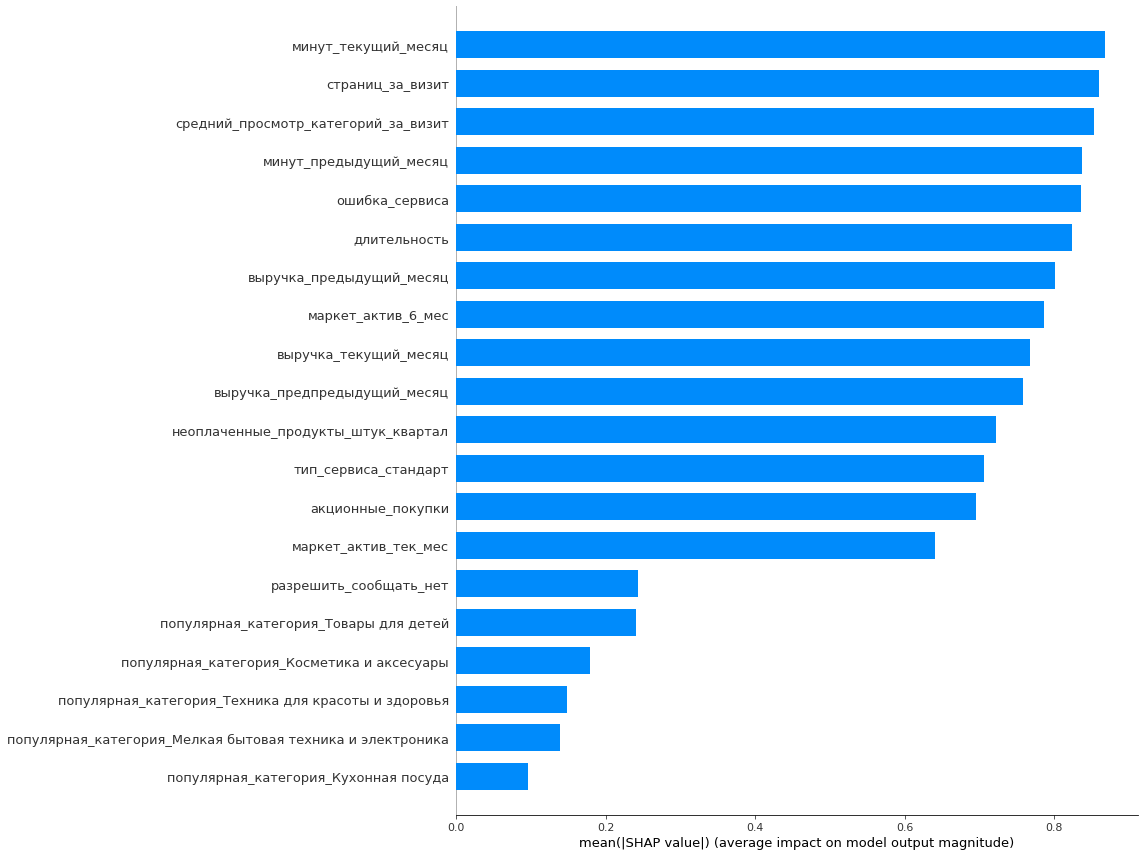

In [100]:
column_transformer = randomized_search.best_estimator_.steps[0][1]
num_feature_names = column_transformer.transformers_[2][2]  

ohe_only_encoder = column_transformer.named_transformers_['ohe_only']
ohe_only_feature_names = ohe_only_encoder.get_feature_names(input_features=column_transformer.transformers_[0][2])

cat_encoder = column_transformer.named_transformers_['cat'] 
cat_feature_names = cat_encoder.get_feature_names(input_features=column_transformer.transformers_[1][2])

feature_names = np.concatenate([ohe_only_feature_names, cat_feature_names, num_feature_names]).tolist()
#print(feature_names)
shap.summary_plot(
    X_test_prep,
    plot_type='bar',
    feature_names=feature_names,
    show=False)
plt.gcf().set_size_inches(16, 12)  # изменяем размер после создания
plt.tight_layout()
plt.show()

- Среди 6 самых пало знначимыз признаков 5 являются типом категории. Также мало значимы: разрешил ли пользователь получать дополнительную информацию

- Сильнее всего на целевой признак влияют: кол-во минут на сайте в текущем месяце, кол-во страниц за визит, средний просмотр категорий за визит.

- По графику важности признаком, можно понять, что покупательскую активность можно в первую очередь определить по поведению пользователя на сайте. Меньше всего следует учитывать что конкретно покупал пользователь.

## Сегментация покупателей

Рассмотрим покупателей с максимально долей покупок по акции и высокой вероятностью снижения покупательской активности

Рассчитаем вероятность снижения покупательской активности для всех покупателей

In [116]:
randomized_search.best_estimator_.classes_

array(['Прежний уровень', 'Снизилась'], dtype=object)

In [103]:
market_full['активность_проба'] = randomized_search.best_estimator_.predict_proba(market_full.drop(['id',
                                                                'покупательская_активность'], axis=1))

Доавим данные о прибыльности покупателей из таблицы `money_df`

In [110]:
market_full = market_full.merge(money_df, on='id').rename(columns={'прибыль' : 'прибыльность'})

Построим диаграмму рассеяния вероятности снижения активности и прибыльности

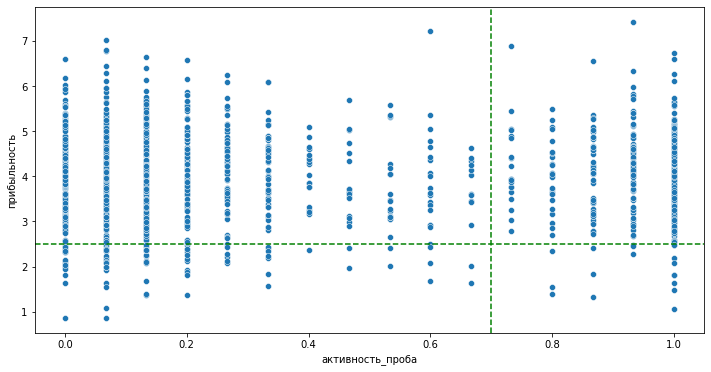

In [126]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=market_full, x='активность_проба', y='прибыльность')
plt.axvline(x=0.7, color='green', linestyle='--')
plt.axhline(y=2.5, color='green', linestyle='--')
plt.show()

Будем рассматривать покупателей с вероятностью снижения активности больше 0.7 и прибыльностью больше 2.5 (верхний правый квадрат на графике)

Выделиим сегмент покупателей, покупающих в основном по акции

In [135]:
prom_customers = market_full.query('акционные_покупки > 0.8 and активность_проба > 0.7 and прибыльность > 2.5')

# все покупатели, кроме рассматриваемых
other_customers = market_full[~market_full['id'].isin(prom_customers['id'])]

Сравним некоторые характеристи у рассматриваемого сегмента и всех остальных

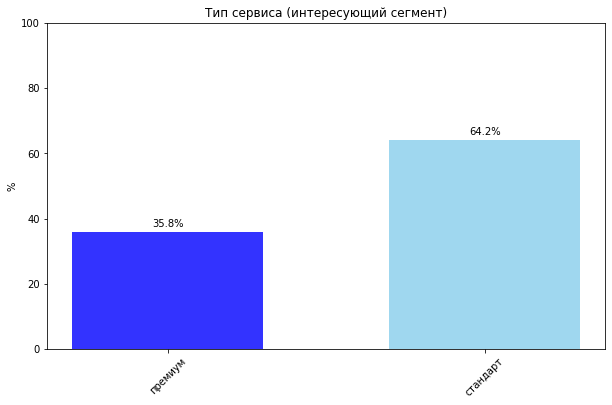

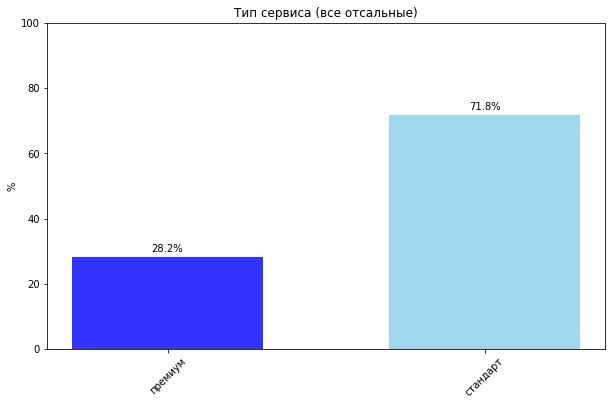

In [149]:
feature_stat_categ(prom_customers['тип_сервиса'], 'Тип сервиса (интересующий сегмент)')
feature_stat_categ(other_customers['тип_сервиса'], 'Тип сервиса (все отсальные)')

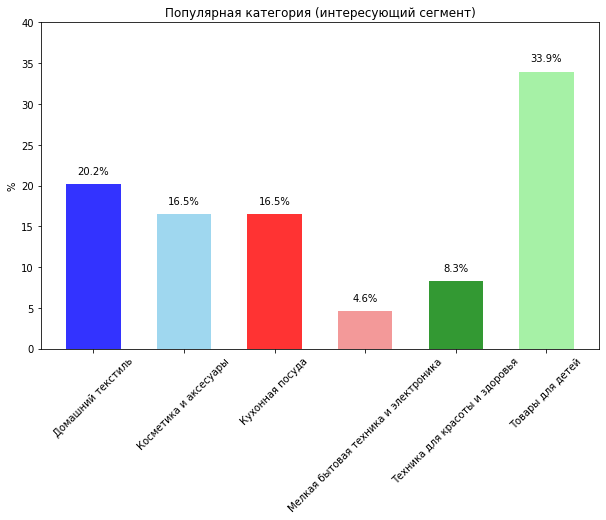

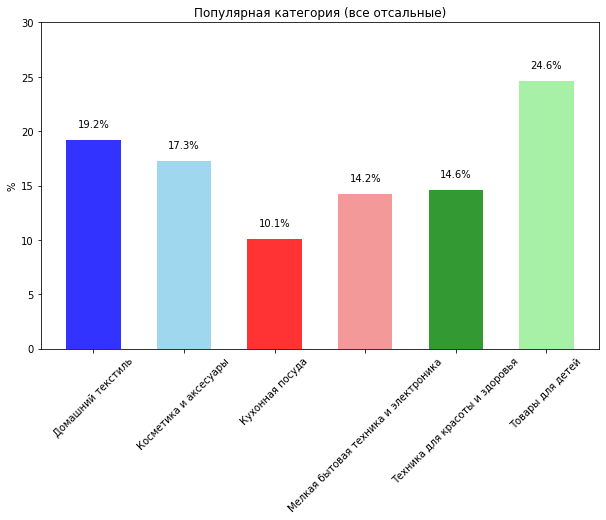

In [148]:
feature_stat_categ(prom_customers['популярная_категория'], 'Популярная категория (интересующий сегмент)', ylim=40)
feature_stat_categ(other_customers['популярная_категория'], 'Популярная категория (все отсальные)', ylim=30)

- У рассматриваемого сегмента также как и у остальных покупателей меньшая часть пользователей обладает премиум подпиской, но их всё же чуть больше. 
- Категория 'Товары для детей' ещё более популярна среди рассматриваемого сегмента, чем среди остальных пользователей.

Из вышеописаных наблюдений, можно составить предложение:

Можно предлагать пользователям из этого сегмента уникальные акции на категорию 'Товары для детей', доступные на сайте только обладателям премиум подписки, таким образом больше людей купят подписку, и у них будет желание её окупить, чаще пользуясь акциями на сайте, что в свою очередь повысит активность на сайте, которая, как показало моделирование, является самым важным признаком, влияющим на покупательскую активность.

## Вывод

По полученным данным была проведена следующая работа

**Предобработка данных**:

Из проблем в данных были замечены опечатки в значениях некоторых столбцов, заказчику рекомендуется ответственней подходить к заполнению данных таблиц

- Удалены опечатки из нескольких столбцов

**Исследовательский аналих данных**:

В датасете был пользователь с аномально большой выручкой, он был удалён.

Количественные переменные практически все распределены нормально. Проблемными являются только два признака:
- `маркет_актив_тек_мес` принимает всего три значения
- в `акционные_покупки` значения чётко делятся на две группы

Среди категориальных признаков практически все распределены равномерно, кроме:
- `тип_сервиса`
- `разрешить_сообщать`

Была создана таблица с покупателями, совершавшими покупки все три последних месяца

**Корреляционный анализ**:

Самая высокая корреляция у целевого признака `покупательская_активность` c признаком `страниц_за_визит`.

Мультиколлинеарности не наблюдается

**Использование пйплайнов**:

Был создан пайплайн для подготовки данных с различными скейлерами и кодировщиками и обучения 4 моделей. С помощью кросс-валидационного поиска были выявлены лучшие настройки:

- Использование OneHotEncoder на категориальных признаках
- Использование StandardScaler на количественных признаках
- kNN с 15 соседями

Метрика ROC-AUC на тренировочной выборке: 0.90

Метрика ROC-AUC на тестовой выборке: 0.92

**Обучени модели логистической регрессии**:

Была построена и обучена модель логистической регрессии с порогом классификации 0.80

С помощью этой модели был предсказан вкус молока коров

**Анализ важности признаков**:

- Среди 7 самых пало знначимыз признаков 5 являются типом категории. Также мало значимы: разрешил ли пользователь получать дополнительную информацию, тип сервиса

- Сильнее всего на целевой признак с отрывом влияет кол-во страниц, посещённых пользователем за визит. Также сильно влияют: средний просмотр категорий за визит, кол-во минут, проведённых на зайте. 

- По графику важности признаком, можно понять, что покупательскую активность можно в первую очередь определить по поведению пользователя на сайте. Меньше всего следует учитывать что конкретно покупал пользователь.

**Сегментация покупателей**

Был выбран сегмент с покупателями, в основном совершающими покупки по акции с высокими показателями прибыльности и вероятности снижения покупательской активности: 

- У рассматриваемого сегмента также как и у остальных покупателей меньшая часть пользователей обладает премиум подпиской, но их всё же чуть больше. 
- Категория 'Товары для детей' ещё более популярна среди рассматриваемого сегмента, чем среди остальных пользователей.

Из вышеописаных наблюдений, было составлено предложение:

Можно предлагать пользователям из этого сегмента уникальные акции на категорию 'Товары для детей', доступные на сайте только обладателям премиум подписки, таким образом больше людей купят подписку, и у них будет желание её окупить, чаще пользуясь акциями на сайте, что в свою очередь повысит активность на сайте, которая, как показало моделирование, является самым важным признаком, влияющим на покупательскую активность.

**Рекоендации заказчику**

- Следить за опечатками в данных столбцов
- При разработке специальных предложений покупателям фокусироваться на повышении активности на сайте
- Для пользователей, в основном совершающими покупки по акции, предлагать уникальные акции на категорию 'Товары для детей', доступные на сайте только обладателям премиум подписки